In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Cargar datasets
logs = pd.read_parquet("dataset_50k_anonymized.parquet")
transacciones = pd.read_csv("hey_transacciones.csv")
clientes = pd.read_csv("hey_clientes.csv")
productos = pd.read_csv("hey_productos.csv")


C:\Users\Bertani\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


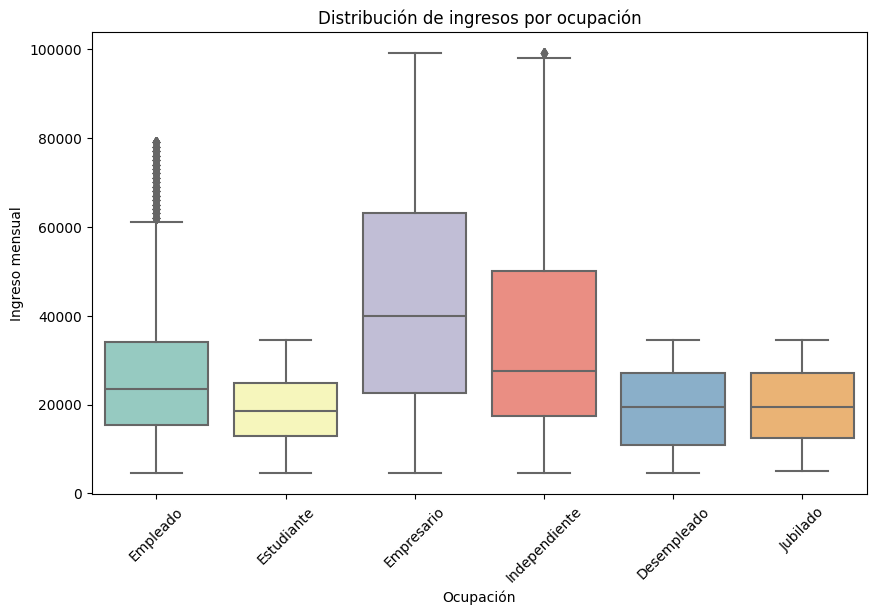

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x="ocupacion", y="ingreso_mensual_mxn", data=clientes, palette="Set3")
plt.title("Distribución de ingresos por ocupación")
plt.xlabel("Ocupación")
plt.ylabel("Ingreso mensual")
plt.xticks(rotation=45)
plt.show()


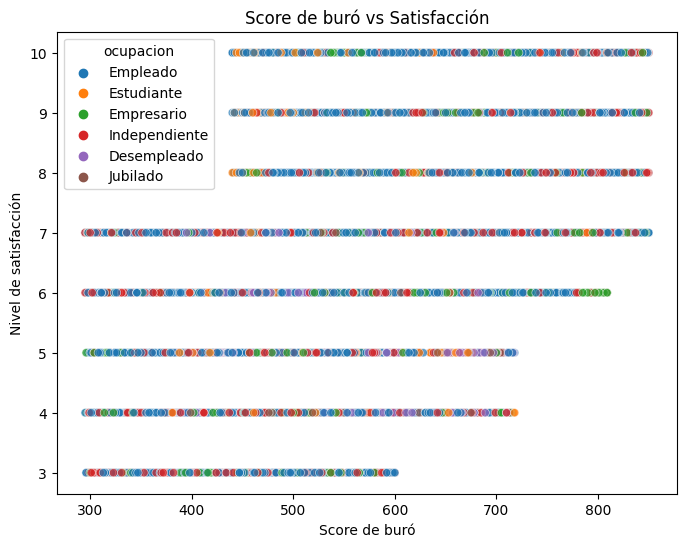

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="score_buro", y="satisfaccion_1_10", hue="ocupacion", data=clientes, alpha=0.7)
plt.title("Score de buró vs Satisfacción")
plt.xlabel("Score de buró")
plt.ylabel("Nivel de satisfacción")
plt.show()


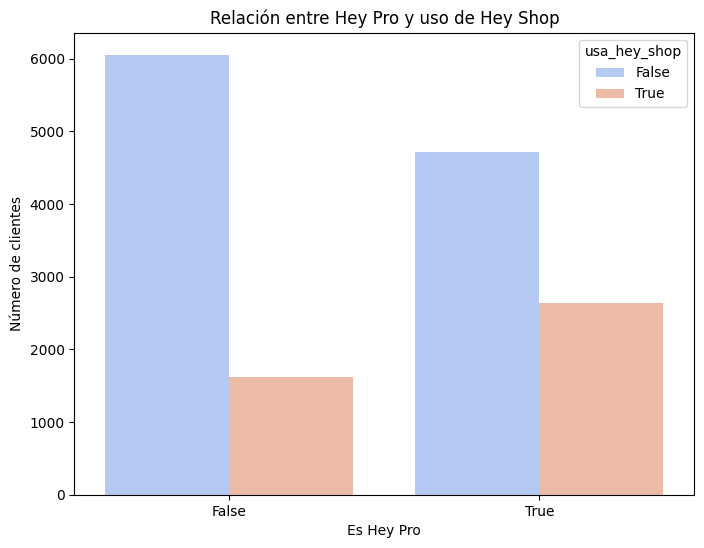

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(x="es_hey_pro", hue="usa_hey_shop", data=clientes, palette="coolwarm")
plt.title("Relación entre Hey Pro y uso de Hey Shop")
plt.xlabel("Es Hey Pro")
plt.ylabel("Número de clientes")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


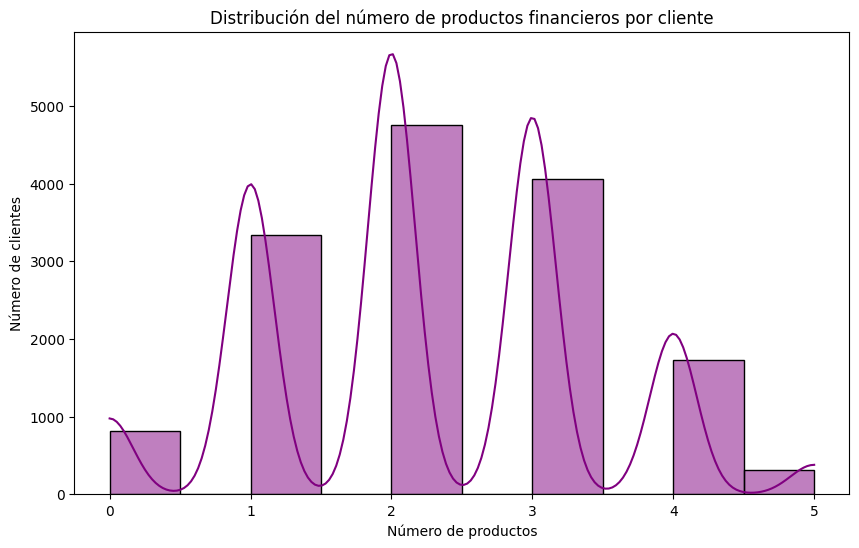

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(clientes["num_productos_activos"], bins=10, kde=True, color="purple")
plt.title("Distribución del número de productos financieros por cliente")
plt.xlabel("Número de productos")
plt.ylabel("Número de clientes")
plt.show()


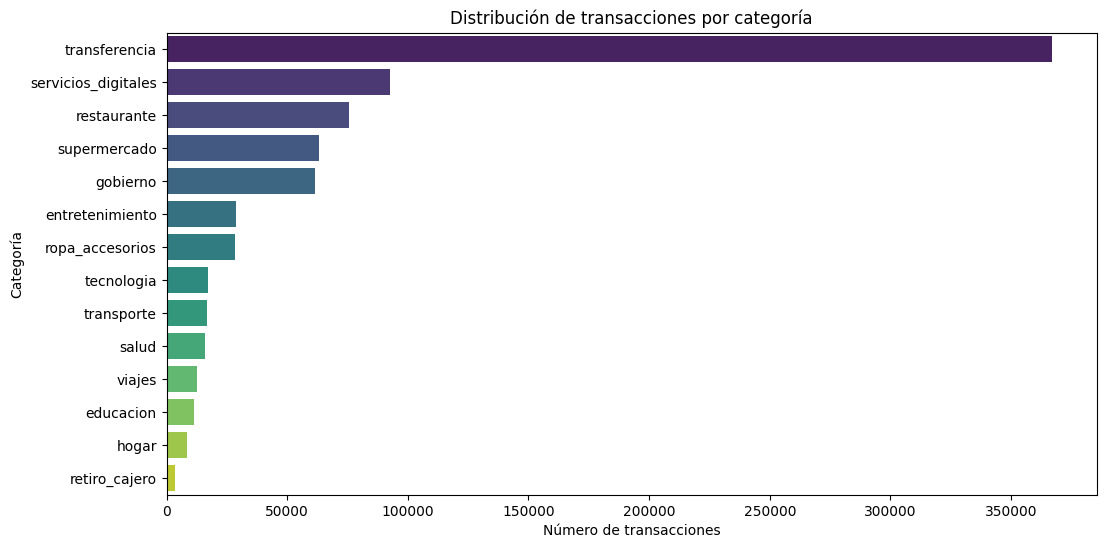

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y="categoria_mcc", data=transacciones, order=transacciones["categoria_mcc"].value_counts().index, palette="viridis")
plt.title("Distribución de transacciones por categoría")
plt.xlabel("Número de transacciones")
plt.ylabel("Categoría")
plt.show()


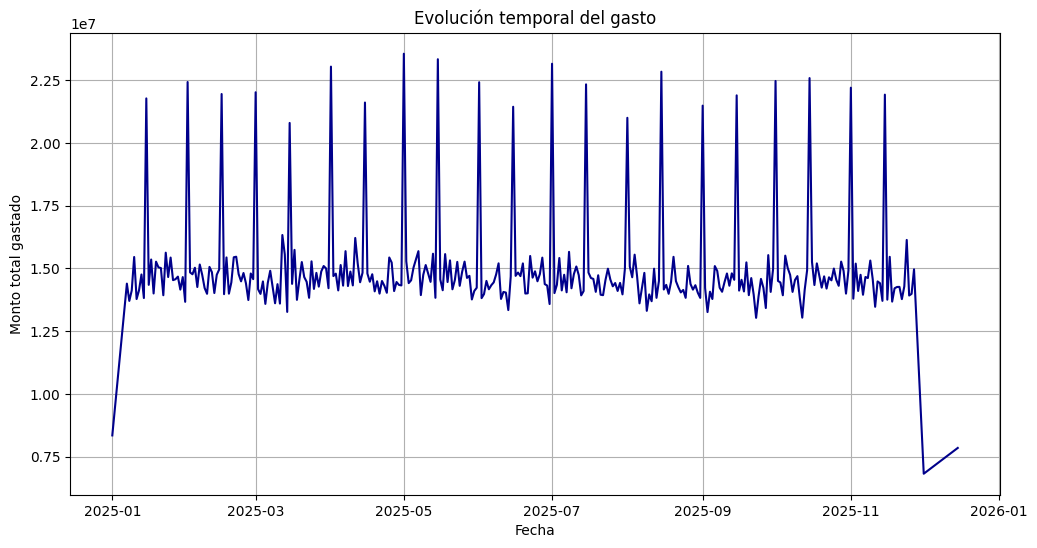

In [14]:
transacciones["fecha_hora"] = pd.to_datetime(transacciones["fecha_hora"])
gasto_diario = transacciones.groupby(transacciones["fecha_hora"].dt.date)["monto"].sum()

plt.figure(figsize=(12,6))
gasto_diario.plot(color="darkblue")
plt.title("Evolución temporal del gasto")
plt.xlabel("Fecha")
plt.ylabel("Monto total gastado")
plt.grid(True)
plt.show()


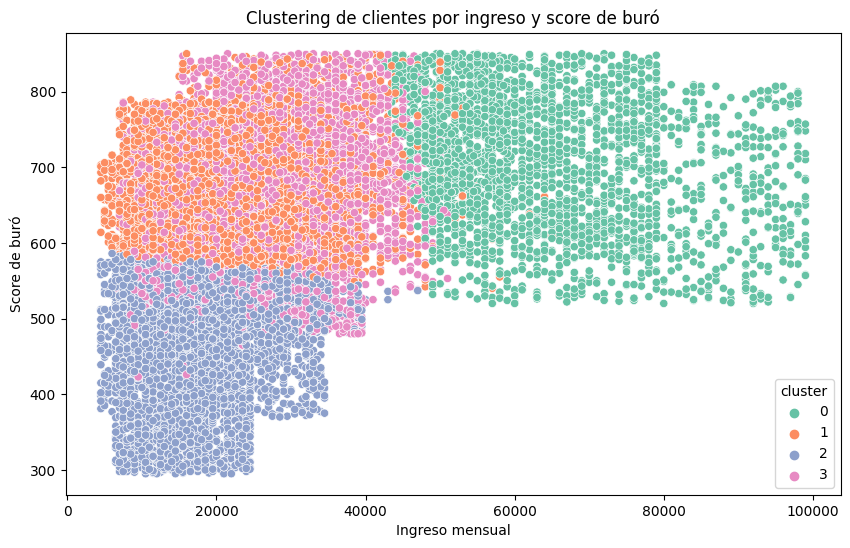

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Selección de variables relevantes
X = clientes[["ingreso_mensual_mxn","score_buro","num_productos_activos"]].fillna(0)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means con 4 clusters (ajustable)
kmeans = KMeans(n_clusters=4, random_state=42)
clientes["cluster"] = kmeans.fit_predict(X_scaled)

# Visualización en 2D (ingreso vs score)
plt.figure(figsize=(10,6))
sns.scatterplot(x="ingreso_mensual_mxn", y="score_buro", hue="cluster", data=clientes, palette="Set2")
plt.title("Clustering de clientes por ingreso y score de buró")
plt.xlabel("Ingreso mensual")
plt.ylabel("Score de buró")
plt.show()


In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk

# Descargar stopwords de NLTK (solo la primera vez)
nltk.download("stopwords")
from nltk.corpus import stopwords

# Stopwords en español
spanish_stopwords = stopwords.words("spanish")

# Preprocesamiento básico
logs["input"] = logs["input"].astype(str)

# Vectorización con stopwords en español
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words=spanish_stopwords)
X_text = vectorizer.fit_transform(logs["input"])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bertani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# LDA con 5 tópicos
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X_text)

# Mostrar palabras más representativas por tópico
n_top_words = 10
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"Tópico {topic_idx+1}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()


Tópico 1:
tarjeta puedo física cómo cambiar solicitar nueva apple pay quiero

Tópico 2:
hola transferencia cargo hice aparece aclaración reconocido reconozco movimiento reportar

Tópico 3:
cuenta dinero puedo si recibir cobro pago quiero cancelar cómo

Tópico 4:
gracias token dice pagar saber deja app necesito día ayuda

Tópico 5:
número atención cuál clientes cliente numero puedes teléfono contacto gracias

Tópico 6:
clabe dónde veo correo opción encuentro intereses clave meses cambio

Tópico 7:
meses crédito cuánto 000 auto personal pesos enganche préstamo monto

Tópico 8:
si tarjeta saldo quiero saber pasa tasa deuda hago compra

Tópico 9:
tarjeta crédito quiero cancelar puedo credito asesor hablar cómo garantía

Tópico 10:
puedo hey banco cómo hacer cuenta puede retirar límite ver



In [7]:
import pyLDAvis
import pyLDAvis.sklearn

pyLDAvis.enable_notebook()
panel = pyLDAvis.sklearn.prepare(lda, X_text, vectorizer, mds='tsne')
panel


ModuleNotFoundError: No module named 'pyLDAvis.sklearn'

In [8]:
pip install pyLDAvis.sklearn

Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement pyLDAvis.sklearn (from versions: none)
ERROR: No matching distribution found for pyLDAvis.sklearn


In [9]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Historial de transacciones
# -----------------------------
# Matriz cliente-producto (frecuencia de compra)
matriz_transacciones = transacciones.pivot_table(index="user_id", columns="producto_id", values="monto", aggfunc="sum", fill_value=0)

# -----------------------------
# 2. Tópicos conversacionales
# -----------------------------
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words=spanish_stopwords)
X_text = vectorizer.fit_transform(logs["input"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_text)

# Distribución de tópicos por conversación
topic_distribution = lda.transform(X_text)

# Agregar distribución de tópicos por cliente
logs["topic_vector"] = list(topic_distribution)
topic_por_cliente = logs.groupby("user_id")["topic_vector"].apply(lambda x: sum(x)/len(x))

# Convertir a DataFrame
topic_df = pd.DataFrame(topic_por_cliente.tolist(), index=topic_por_cliente.index)

In [13]:
topic_df

,0,1,2,3,4
user_id,,,,,
USR-00001,0.144725,0.047246,0.552113,0.208914,0.047002
USR-00002,0.095287,0.296666,0.047035,0.121616,0.439395
USR-00003,0.358877,0.053163,0.236626,0.134234,0.217100
USR-00004,0.036156,0.083226,0.586292,0.036010,0.258317
USR-00005,0.059657,0.059796,0.166554,0.368811,0.345182
...,...,...,...,...,...
USR-15021,0.172671,0.186228,0.264807,0.279725,0.096569
USR-15022,0.558545,0.243474,0.080485,0.054095,0.063401
USR-15023,0.214703,0.129939,0.294113,0.158435,0.202810


In [10]:
# -----------------------------
# 3. Fusionar señales híbridas
# -----------------------------
# Concatenar matrices: transacciones + tópicos
perfil_cliente = pd.concat([matriz_transacciones, topic_df], axis=1).fillna(0)

In [14]:
perfil_cliente

,PRD-00000001,PRD-00000002,PRD-00000003,PRD-00000004,PRD-00000005,PRD-00000006,PRD-00000007,PRD-00000008,PRD-00000009,PRD-00000010,...,PRD-00038904,PRD-00038905,PRD-00038906,PRD-00038907,PRD-00038909,0,1,2,3,4
user_id,,,,,,,,,,,,,,,,,,,,,
USR-00001,111177.81,8392.78,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.144725,0.047246,0.552113,0.208914,0.047002
USR-00002,0.00,0.00,199944.39,12778.28,0.00,0.00,0.00,0.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.095287,0.296666,0.047035,0.121616,0.439395
USR-00003,0.00,0.00,0.00,0.00,176494.68,14306.41,0.00,0.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.358877,0.053163,0.236626,0.134234,0.217100
USR-00004,0.00,0.00,0.00,0.00,0.00,0.00,204341.99,340000.0,35771.75,0.00,...,0.00,0.00,0.00,0.00,0.00,0.036156,0.083226,0.586292,0.036010,0.258317
USR-00005,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,171884.57,...,0.00,0.00,0.00,0.00,0.00,0.059657,0.059796,0.166554,0.368811,0.345182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USR-15021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.172671,0.186228,0.264807,0.279725,0.096569
USR-15022,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.558545,0.243474,0.080485,0.054095,0.063401
USR-15023,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,...,230110.76,0.00,0.00,0.00,0.00,0.214703,0.129939,0.294113,0.158435,0.202810


In [11]:
# -----------------------------
# 4. Similaridad entre clientes
# -----------------------------
similaridad = cosine_similarity(perfil_cliente)

In [15]:
similaridad

array([[1.00000000e+00, 4.46928065e-12, 1.13126513e-11, ...,
        9.44135517e-12, 3.04640898e-11, 2.93383078e-12],
       [4.46928065e-12, 1.00000000e+00, 4.87118605e-12, ...,
        3.93079954e-12, 1.99515360e-11, 3.12719883e-12],
       [1.13126513e-11, 4.87118605e-12, 1.00000000e+00, ...,
        5.37106316e-12, 1.91115564e-11, 2.80443035e-12],
       ...,
       [9.44135517e-12, 3.93079954e-12, 5.37106316e-12, ...,
        1.00000000e+00, 1.52872479e-11, 1.98739714e-12],
       [3.04640898e-11, 1.99515360e-11, 1.91115564e-11, ...,
        1.52872479e-11, 1.00000000e+00, 1.15962349e-11],
       [2.93383078e-12, 3.12719883e-12, 2.80443035e-12, ...,
        1.98739714e-12, 1.15962349e-11, 1.00000000e+00]])

In [12]:
# -----------------------------
# 5. Función de recomendación
# -----------------------------
def recomendar_productos(user_id, top_n=5):
    # Índice del cliente
    idx = perfil_cliente.index.get_loc(user_id)
    
    # Similaridad con otros clientes
    scores = list(enumerate(similaridad[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    
    # Tomar clientes similares
    clientes_similares = [perfil_cliente.index[i] for i, _ in scores[1:6]]
    
    # Productos comprados por clientes similares
    productos_similares = matriz_transacciones.loc[clientes_similares].sum().sort_values(ascending=False)
    
    # Excluir productos ya comprados por el cliente
    productos_cliente = matriz_transacciones.loc[user_id]
    recomendados = productos_similares[productos_cliente == 0].head(top_n)
    
    return recomendados

# Ejemplo de uso
print(recomendar_productos("USR-00001", top_n=5))


producto_id
PRD-00018228    4908.61
PRD-00009708    4583.91
PRD-00004856    3310.04
PRD-00027857    2672.12
PRD-00036322    2405.35
dtype: float64


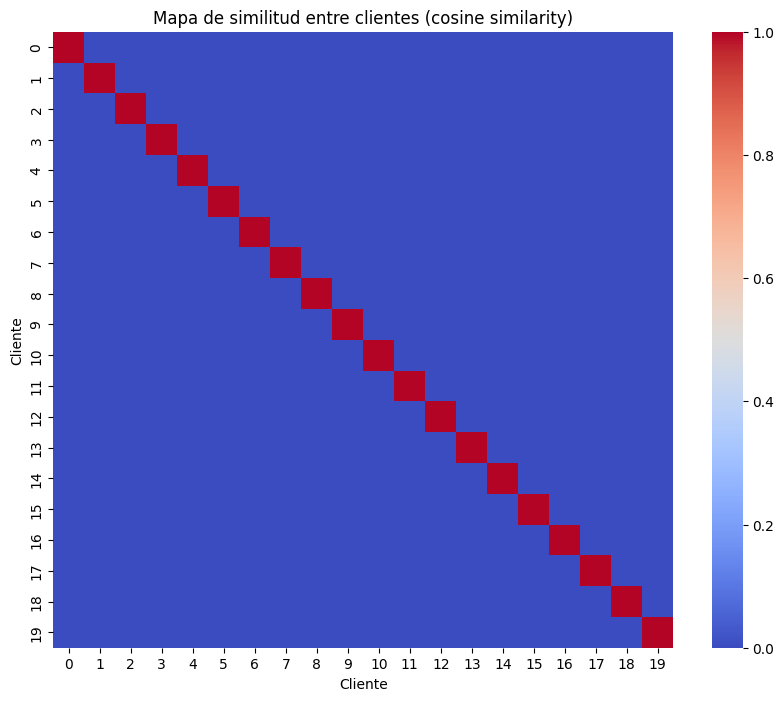

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap de similitud (cosine similarity)
plt.figure(figsize=(10,8))
sns.heatmap(similaridad[:20,:20], cmap="coolwarm", annot=False)  # ejemplo con 20 clientes
plt.title("Mapa de similitud entre clientes (cosine similarity)")
plt.xlabel("Cliente")
plt.ylabel("Cliente")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


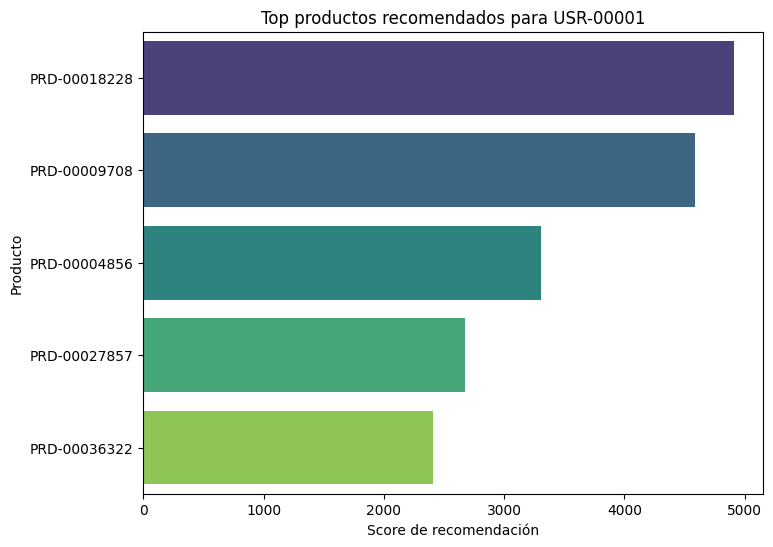

In [17]:
# Obtener recomendaciones para un cliente
recomendados = recomendar_productos("USR-00001", top_n=5)

plt.figure(figsize=(8,6))
sns.barplot(x=recomendados.values, y=recomendados.index, palette="viridis")
plt.title("Top productos recomendados para USR-00001")
plt.xlabel("Score de recomendación")
plt.ylabel("Producto")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


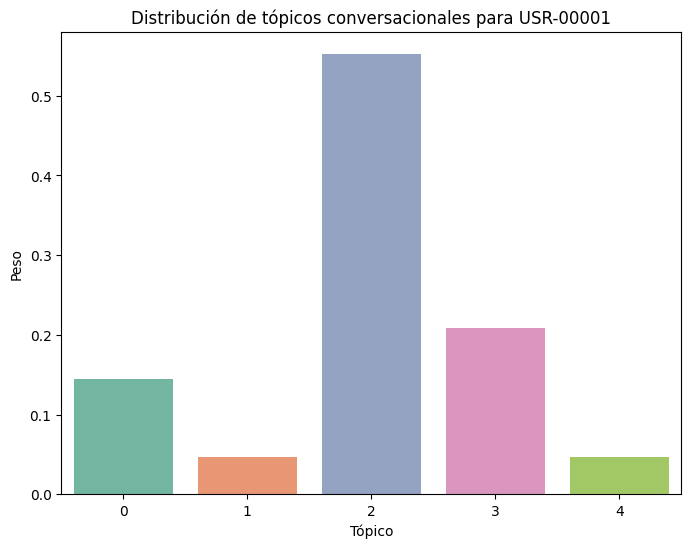

In [18]:
# Ejemplo: distribución de tópicos para un cliente
cliente_topics = topic_df.loc["USR-00001"]

plt.figure(figsize=(8,6))
sns.barplot(x=cliente_topics.index, y=cliente_topics.values, palette="Set2")
plt.title("Distribución de tópicos conversacionales para USR-00001")
plt.xlabel("Tópico")
plt.ylabel("Peso")
plt.show()


In [9]:
# Contar número de transacciones por cliente
frecuencia = transacciones.groupby("user_id")["transaccion_id"].count()

# Agregar al dataset de clientes
clientes = clientes.merge(frecuencia.rename("frecuencia_compra"), on="user_id", how="left")
clientes["frecuencia_compra"] = clientes["frecuencia_compra"].fillna(0)
